# <span style="color:green"> Numerical Simulation Laboratory (NSL) </span>
## <span style="color:blue">  Numerical exercises 10</span>

### Exercise 10.1

By adapting your Genetic Algorithm code, developed during the Numerical Exercise 9, write a C++ code to solve the TSP with a **Simulated Annealing** (SA) algorithm. Apply your code to the optimization of a path among 

- 30 cities randomly placed on a circumference
- 30 cities randomly placed inside a square

Show your results via:

- a picture of the length of the best path as a function of the iteration of your algorithm
- a picture of the best path

# Simulated Annealing #
------------

This lab (and the program) follows the previous one (LSN 9). As we will see, the principles and the code are quite similar (generating populations, computing costs), with the obvious difference that the candidate solutions are seeked with a **Simulated Annealing** (SA) algorithm.

The term "annealing" comes from material science. It is the process to heat up a material and letting it cool down towards a desired stable state. This idea can be transfered to the resulution of the TSP. The intuition behind it is to treat the cost of a tour as the energy. A random tour has a high cost (high energy) while a tour close to optimum has a low energy.

To avoid any confusion from now on, I will still use the term "cost" instead of energy. To find the optimal tour, the algorithm "proposes" a new tour and compares the cost of the new tour against the previous one. If the cost is higher, it is rejected and a new one is proposed. Otherwise it is accepted and the algorithm proceeds.


# One-Dimensional TSP with SA #
---------

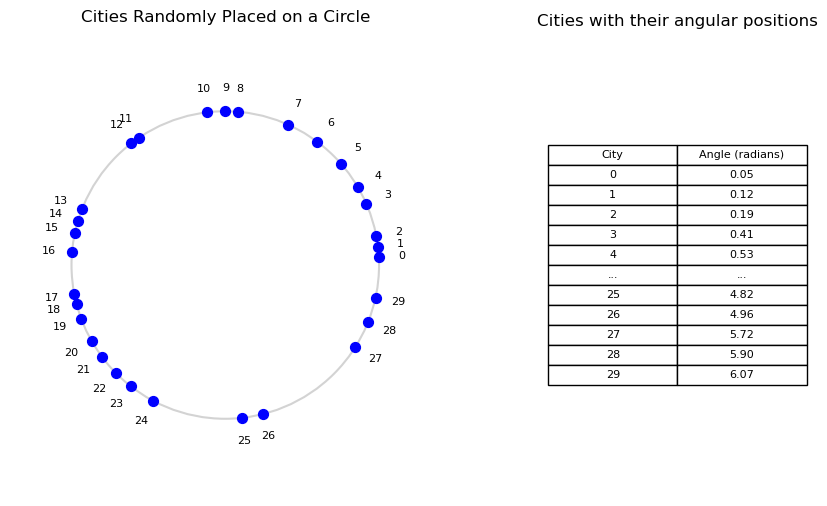

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import random

random.seed(1234)
number_of_cities = 30
min_gap = 0.05

angular_positions = []

# Every time the random generator proposes a cadidate angular position we check if this position is far enough
# from the other positions. If so we reject the candidate, if not we accept it.
# The loop continues until all positions have been created
while len(angular_positions) < number_of_cities:
    candidate = round(random.uniform(0, 2*np.pi), 2)
    if all(abs(candidate - a) > min_gap for a in angular_positions):
        angular_positions.append(candidate)

sorted_angular_positions = sorted(angular_positions)
cities_database = np.column_stack((np.arange(number_of_cities), sorted_angular_positions))
#print(cities_database)

np.savetxt(
    "./TSP_Annealing_Source/Data/linear_cities_database.dat",
    cities_database,
    fmt=['%d', '%.2f'],
    delimiter=",",     
    header="City_label,Angle_radians",
    comments=''
)

radius = 1.0
x = radius * np.cos(sorted_angular_positions)
y = radius * np.sin(sorted_angular_positions)

fig, (ax_circle, ax_table) = plt.subplots(1, 2, figsize=(10, 6), gridspec_kw={'width_ratios': [2, 1]})
fig.subplots_adjust(wspace=0.4)  # spacing between circle and table

ax_circle.set_aspect('equal', adjustable='box')
circle = plt.Circle((0, 0), radius, color='lightgrey', fill=False, linewidth=1.5)
ax_circle.add_artist(circle)
ax_circle.scatter(x, y, color='blue', s=50, zorder=3)

for i in range(number_of_cities):
    ax_circle.text(x[i] * 1.15, y[i] * 1.15, str(i), ha='center', va='center', fontsize=8)

ax_circle.set_xlim(-radius * 1.4, radius * 1.4)
ax_circle.set_ylim(-radius * 1.4, radius * 1.4)
ax_circle.axis('off')
ax_circle.set_title("Cities Randomly Placed on a Circle", pad=20)

# Shows the first 'head' and last 'tail' rows, with dots in the middle.
def truncate_table(data, head=5, tail=5):
    if len(data) <= head + tail:
        return data 
    return np.vstack([
        data[:head],
        [["...", "..."]],
        data[-tail:]
    ])

table_data_full = [[int(row[0]), f"{row[1]:.2f}"] for row in cities_database]
table_data = truncate_table(np.array(table_data_full, dtype=object))
column_labels = ["City", "Angle (radians)"]

table = ax_table.table(cellText=table_data, colLabels=column_labels, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.2)
ax_table.set_title('Cities with their angular positions')
ax_table.axis('off')

plt.show()

Reference (Optimal) Cost = 6.28319


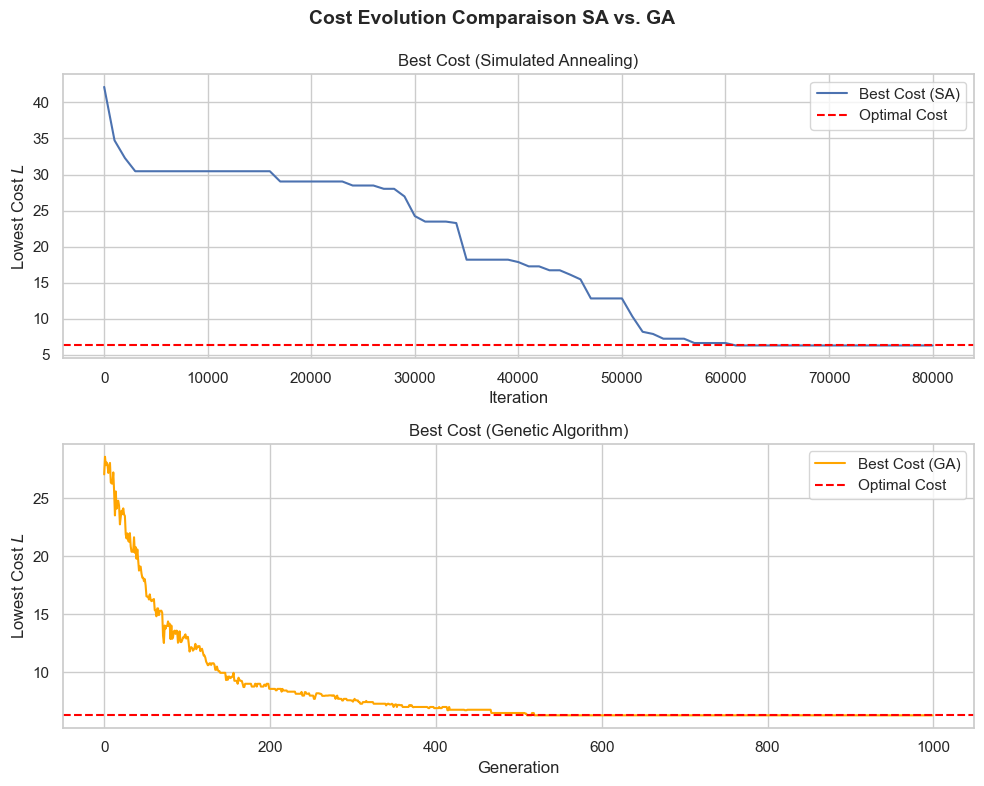

In [2]:
# Saving the reference value
with open("./TSP_Annealing_Source/Data_out/cost_evolution.dat") as f:
    first_line = f.readline().strip()
ref_value = float(first_line.split(",")[1])
print("Reference (Optimal) Cost =", ref_value)

df_sa = pd.read_csv("./TSP_Annealing_Source/Data_out/sa_cost_evolution.dat", sep=",")
df_ga = pd.read_csv("./TSP_Annealing_Source/Data_out/cost_evolution.dat", skiprows=1, sep=",")

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2,1, figsize=(10,8), sharex=False)

sns.lineplot(ax=axes[0], x="Iteration", y="BestCost", label="Best Cost (SA)", data=df_sa)
axes[0].axhline(y=ref_value, color="red", linestyle="--", label="Optimal Cost")
axes[0].set_title("Best Cost (Simulated Annealing)")
axes[0].set_ylabel(r'Lowest Cost $L$')
axes[0].legend(loc="best")

sns.lineplot(ax=axes[1], x="Generation", y="BestCost",  label="Best Cost (GA)", data=df_ga, color="orange")
axes[1].axhline(y=ref_value, color="red", linestyle="--", label="Optimal Cost")
axes[1].set_title("Best Cost (Genetic Algorithm)")
axes[1].set_ylabel(r'Lowest Cost $L$')
axes[1].set_xlabel("Generation")
axes[1].legend(loc="best")

fig.suptitle("Cost Evolution Comparaison SA vs. GA", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.subplots_adjust(top=0.9)

plt.show()

# Two-Dimensional TSP with SA #
------------

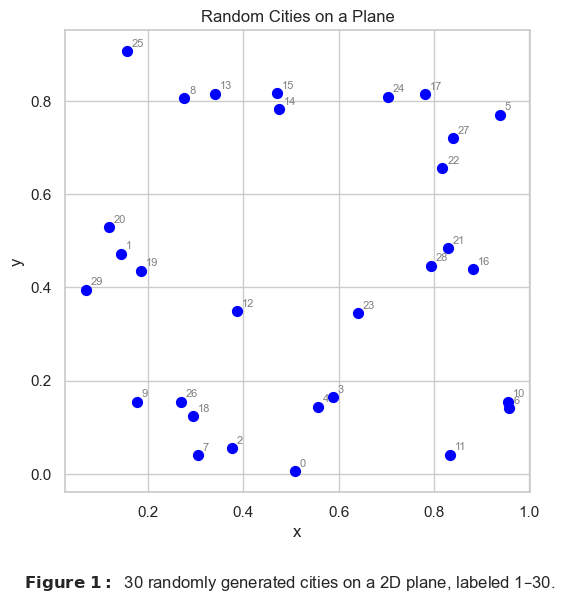

In [3]:
number_of_cities = 30

# Generate 30 random points (x, y) in the unit square [0,1] x [0,1]
cities = [(round(random.uniform(0, 1), 4), round(random.uniform(0, 1), 4)) 
          for _ in range(number_of_cities)]

cities_array = np.array(cities)  # shape (30, 2)

# Combine city index with coordinates
plane_cities_database = np.column_stack((np.arange(number_of_cities), cities_array))

#print(plane_cities_database)

# ----- Saving the database into a .dat file
np.savetxt(
    "./TSP_Annealing_Source/Data/plane_cities_database.dat",
    plane_cities_database,
    fmt=['%d', '%.2f', '%.2f'], # fmt = "format" (d = integer, f = float, ..)
    delimiter=",",     
    header="City_label,x_position,y_position",
)

labels = plane_cities_database[:,0]
x_coords = plane_cities_database[:,1]
y_coords = plane_cities_database[:,2]

plt.figure(figsize=(6,6))
plt.scatter(x_coords,y_coords,color="blue",s=50)

for i, label in enumerate(labels):
    plt.text(x_coords[i]+0.01, y_coords[i]+0.01, str(int(label)), fontsize=8, color='grey')

plt.xlabel("x")
plt.ylabel("y")
plt.title("Random Cities on a Plane")
plt.grid(True)

plt.figtext(
    0.5, -0.05, 
    r"$\mathbf{Figure\ 1:}$  30 randomly generated cities on a 2D plane, labeled 1–30.", 
    ha="center", fontsize=12
)

plt.show()

## Plotting the best tour ##

Generation: 99999
Tour: [0, 2, 7, 18, 26, 9, 29, 19, 1, 20, 25, 8, 13, 15, 14, 24, 17, 5, 27, 22, 21, 28, 16, 10, 6, 11, 23, 12, 3, 4, 0]


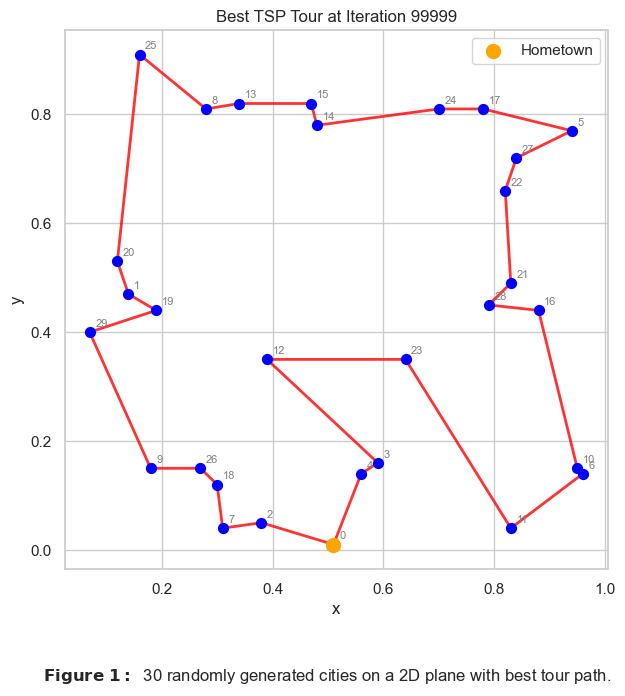

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import random

filename = "./TSP_Annealing_Source/Data_out/sa_best_tour_2D.dat"

with open(filename, "r") as f:
    lines = [line.strip() for line in f.readlines() if line.strip()]

last_line = lines[-1]
parts = last_line.split(",")

generation = int(parts[0])
tour = [int(x) for x in parts[1:] if x.strip().isdigit()]

print(f"Generation: {generation}")
print(f"Tour: {tour}")

number_of_cities = 30

plane_cities_database = np.loadtxt(
    "./TSP_Annealing_Source/Data/plane_cities_database.dat",
    delimiter=",",
    skiprows=1
)

labels = plane_cities_database[:, 0]
x_coords = plane_cities_database[:, 1]
y_coords = plane_cities_database[:, 2]

plt.figure(figsize=(7, 7))
plt.scatter(x_coords, y_coords, color="blue", s=50, zorder=2)

# Add city labels
for i, label in enumerate(labels):
    plt.text(x_coords[i] + 0.01, y_coords[i] + 0.01, str(int(label)),
             fontsize=8, color='grey')

tour_x = [x_coords[i] for i in tour]
tour_y = [y_coords[i] for i in tour]

plt.plot(tour_x, tour_y, color="red", linewidth=2, alpha=0.8, zorder=1)
plt.scatter(tour_x[0], tour_y[0], color="orange", s=100, label="Hometown", zorder=3)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Best TSP Tour at Iteration {generation}")
plt.grid(True)
plt.legend()

plt.figtext(
    0.5, -0.05,
    r"$\mathbf{Figure\ 1:}$  30 randomly generated cities on a 2D plane with best tour path.",
    ha="center", fontsize=12
)

plt.show()

### Exercise 10.2

Parallelize with MPI libraries your Simulated Annealing code in order to solve the TSP by performing a *Random Search* with **parallel SA searches of the optimal path**:
each node should perform an independent SA search and only in the end you will compare the results of each node.
Apply your code to the *usual* TSP problems above.

# Parallel SA #
----------

## Message Passing Interface (MPI) ##

MPI is a standardized framework for parallel computing. It will allow us to distribute our SA on multiple processors or even on multiple computers. It is implemented as a full ```c++```library: ```MPI```which we are going to use in our code. 

Note: to properly import and use ```MPI```library it is necessary to update this line in the ```Makefile```: ```CXX = mpic++  # Using MPI C++ compiler wrapper```.

## Simulated Annealing MPI routines ##

I have added two new routines to my main program, respectively ```void oneDim_TSP_SA_Routine_MPI()```and ```void twoDim_TSP_SA_Routine_MPI()```. The structure is almost identical to the previous SA routines but with a key difference: each routine runs four independent "version" of the algorithm in parrallel. Concretely, each version of the algorithm is istanciated with a different seed and is identified with a "rank" (unique ID number).

The **core idea** behind running the same algorithm started with different seeds in parallel is to make them "race" and pick the fastest and best solution among the four.

## Workflow ##

- Each rank starts with a different seed: ```unsigned int seed = 12345 + rank```
- Each sub-processes work with the total number of iterations.
- The best result among the four is selected as the optimal solution. 

## Usage ##

I wrote my program with an interactive menu, where I invite the user to choose between different routines (GA, SA, 1D, 2D, etc.). However, to run ```MPI```on many ranks the user must execute the program the following way:

```mpirun -np 4 ./TSP```

which translates in plain english “Start my program TSP 4 times in parallel and let each instance communicate with MPI.” In my program I enforced the option to use 4 ranks exactly. On some machines one must run:

```mpirun --mca oob_tcp_if_include lo -np 4 ./TSP```

the additional flag tells MPI to only use the loopback network for its internal communications. This is the case if the parallel process is meant to run only on the machine on which the main program is executed (as opposed to many machines distributed on a network).

Reference (Optimal) Cost = 6.28319


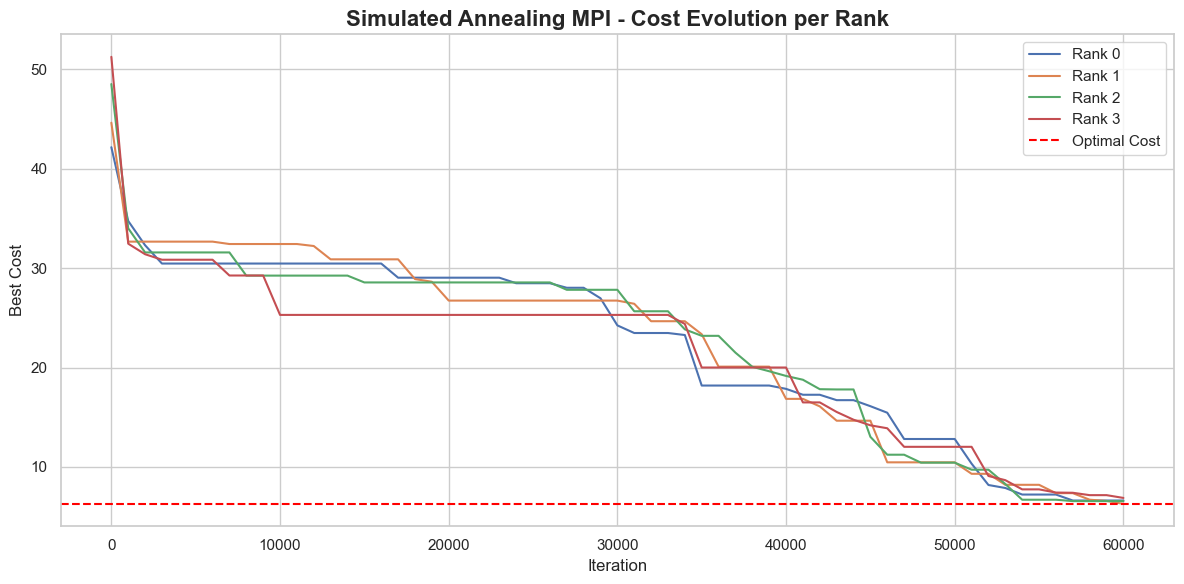

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "./TSP_Annealing_Source/Data_out/sa_cost_evolution_1D_MPI.dat"

df = pd.read_csv(file_path)

ref_file = "./TSP_Annealing_Source/Data_out/cost_evolution.dat"
with open(ref_file) as f:
    first_line = f.readline().strip()
ref_value = float(first_line.split(",")[1])
print("Reference (Optimal) Cost =", ref_value)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Plot each rank
for i in range(4):
    col_name = f"BestCostRank{i}"
    if col_name in df.columns:
        plt.plot(df["Iteration"], df[col_name], label=f"Rank {i}")

plt.axhline(y=ref_value, color="red", linestyle="--", label="Optimal Cost")

plt.title("Simulated Annealing MPI - Cost Evolution per Rank", fontsize=16, fontweight="bold")
plt.xlabel("Iteration")
plt.ylabel("Best Cost")
plt.legend(loc="best")
plt.tight_layout()

plt.show()

## Two-Dimensional Case ##

**Usage**: run the following command ```mpirun -np 4 ./TSP 2D```

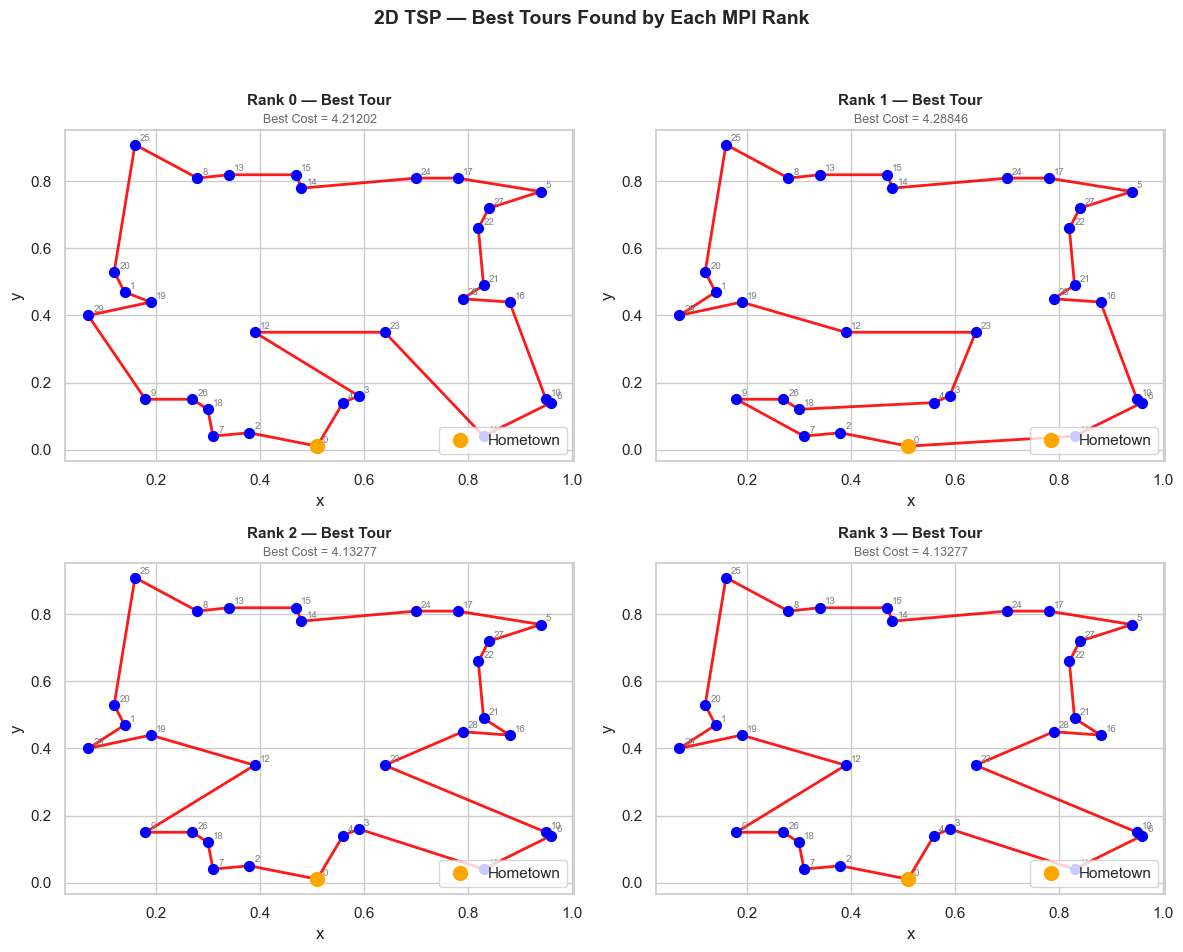

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os

base_dir = "./TSP_Annealing_Source/Data_out"
city_file = "./TSP_Annealing_Source/Data/plane_cities_database.dat"
n_ranks = 4

try:
    plane = np.loadtxt(city_file, delimiter=",", skiprows=1)
except Exception as e:
    raise SystemExit(f"Failed to load city file '{city_file}': {e}")

labels = plane[:, 0].astype(int)
x_coords = plane[:, 1]
y_coords = plane[:, 2]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for rank in range(n_ranks):
    tour_path = os.path.join(base_dir, f"sa_best_tour_2D_rank{rank}.dat")
    cost_path = os.path.join(base_dir, f"sa_best_cost_2D_rank{rank}.dat")
    ax = axes[rank]

    if not os.path.exists(tour_path):
        print(f"Warning: Missing tour file for rank {rank}: {tour_path}")
        ax.text(0.5, 0.5, f"No tour file for rank {rank}", ha="center", va="center")
        ax.set_title(f"Rank {rank} — Missing")
        ax.axis('off')
        continue

    if not os.path.exists(cost_path):
        print(f"Warning: Missing cost file for rank {rank}: {cost_path}")
        best_cost = None
    else:
        try:
            with open(cost_path, "r") as cf:
                lines = [ln.strip() for ln in cf.readlines() if ln.strip()]
            best_cost = None
            for ln in lines:
                try:
                    best_cost = float(ln)
                    break
                except ValueError:
                    continue
        except Exception as e:
            print(f"Warning: could not read cost file for rank {rank}: {e}")
            best_cost = None

    try:
        with open(tour_path, "r") as tf:
            content = tf.read().strip()

        tokens = [t.strip() for t in content.replace("\n", ",").split(",") if t.strip()]
        tour = []
        for t in tokens:
            try:
                tour.append(int(t))
            except ValueError:
                # skip non-integer tokens
                pass

        if len(tour) == 0:
            raise ValueError("No integer city indices found in tour file.")
    except Exception as e:
        print(f"Warning: could not parse tour file for rank {rank}: {e}")
        ax.text(0.5, 0.5, f"Bad tour file for rank {rank}", ha="center", va="center")
        ax.set_title(f"Rank {rank} — Error")
        ax.axis('off')
        continue

    ax.scatter(x_coords, y_coords, color="blue", s=50, zorder=2)

    for i, lab in enumerate(labels):
        ax.text(x_coords[i] + 0.01, y_coords[i] + 0.01, str(int(lab)), fontsize=7, color='grey')

    if tour[0] != tour[-1]:
        tour.append(tour[0])

    valid_tour = [c for c in tour if 0 <= c < len(x_coords)]
    tour_x = [x_coords[i] for i in valid_tour]
    tour_y = [y_coords[i] for i in valid_tour]

    ax.plot(tour_x, tour_y, color="red", linewidth=2, alpha=0.9, zorder=1)
    ax.scatter(tour_x[0], tour_y[0], color="orange", s=100, zorder=3, label="Hometown")

    ax.set_title(f"Rank {rank} — Best Tour\n", fontsize=11, fontweight='bold')
    subtitle = f"Best Cost = {best_cost:.5f}" if best_cost is not None else "Best Cost = N/A"

    ax.text(0.5, 1.02, subtitle, transform=ax.transAxes, ha="center", fontsize=9, color='dimgray')

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True)
    ax.legend(loc="lower right")

fig.suptitle("2D TSP — Best Tours Found by Each MPI Rank", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()